## What factors best predict whether an NFL offense will successfully convert a fourth-down attempt during a game from data 2022-2024??

2020 done.
2021 done.
2022 done.
2023 done.
2024 done.
Downcasting floats.
Accuracy: 0.616
ROC AUC: 0.642
              precision    recall  f1-score   support

           0       0.65      0.68      0.66       337
           1       0.57      0.54      0.55       267

    accuracy                           0.62       604
   macro avg       0.61      0.61      0.61       604
weighted avg       0.61      0.62      0.61       604

Baseline accuracy: 0.558


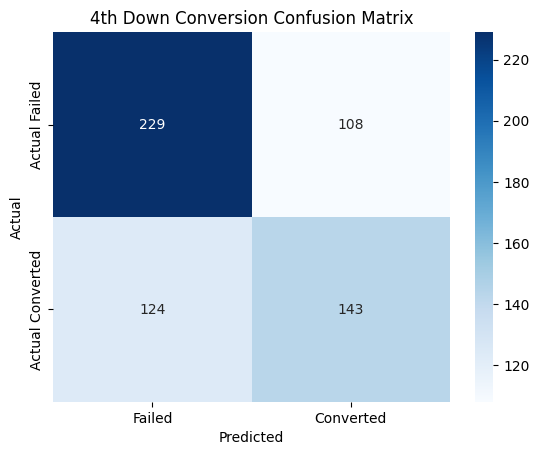

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve
from nfl_data_py import import_pbp_data

seasons = [2020, 2021, 2022, 2023, 2024]
pbp = import_pbp_data(seasons)

df = pbp[(pbp["down"] == 4) & (pbp["play_type"].isin(["pass", "rush"]))].copy()

if "yards_to_go" not in df.columns:
    if "ydstogo" in df.columns:
        df["yards_to_go"] = df["ydstogo"]
    else:
        df["yards_to_go"] = 0

df["yards_to_go"] = df["yards_to_go"].fillna(0)
df["yards_gained"] = df["yards_gained"].fillna(0)
df["success"] = (df["yards_gained"] >= df["yards_to_go"]).astype(int)

df["goal_to_go"] = (df["yardline_100"] <= 10).astype(int)
df["red_zone"] = (df["yardline_100"] <= 20).astype(int)
df["score_diff"] = df["score_differential"].fillna(0)

X = df[["yards_to_go", "yardline_100", "goal_to_go", "red_zone", "score_diff", "play_type"]]
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), ["yards_to_go", "yardline_100", "goal_to_go", "red_zone", "score_diff"]),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["play_type"])
    ]
)

model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Failed", "Converted"],
            yticklabels=["Actual Failed", "Actual Converted"])
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 3))

plt.title("4th Down Conversion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




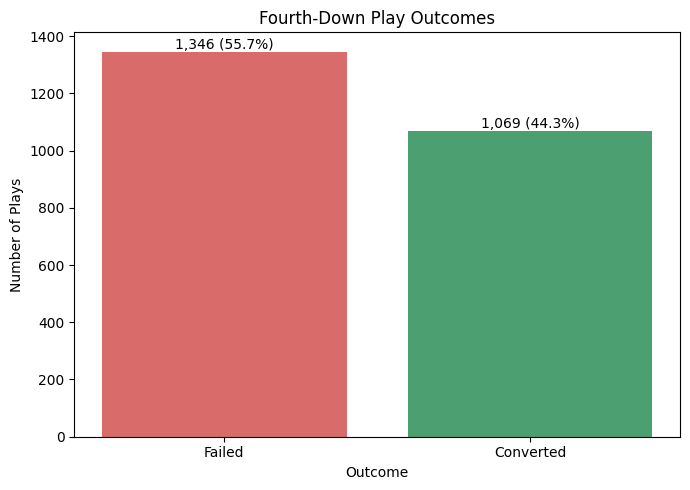

In [15]:
counts = df["success"].value_counts().reindex([0, 1], fill_value=0)
labels = ["Failed", "Converted"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values, color=["#d96b6b", "#4c9f70"])

ax.set_title("Fourth-Down Play Outcomes")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of Plays")

total = counts.sum()
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,} ({count / total:.1%})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [16]:
distance_bins = [0, 2, 5, 10, 20, float("inf")]
distance_labels = ["1–2", "3–5", "6–10", "11–20", "21+"]

df["distance_group"] = pd.cut(
    df["yards_to_go"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

print("Conversion rate by yards to go and play type:")
display(
    df.pivot_table(
        index="distance_group",
        columns="play_type",
        values="success",
        aggfunc="mean",
        observed=False
    ).round(3)
)

print("\nPlay counts by distance:")
display(df["distance_group"].value_counts(sort=False))

print("\nPotential outliers (IQR rule):")
for col in ["yards_to_go", "yards_gained", "yardline_100"]:
    values = df[col].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = values[(values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)]
    print(f"{col}: {len(outliers):,} potential outliers")

Conversion rate by yards to go and play type:


play_type,pass
distance_group,
1–2,0.565
3–5,0.482
6–10,0.343
11–20,0.188
21+,0.071



Play counts by distance:


1–2      828
3–5      763
6–10     537
11–20    245
21+       42
Name: distance_group, dtype: int64


Potential outliers (IQR rule):
yards_to_go: 164 potential outliers
yards_gained: 178 potential outliers
yardline_100: 3 potential outliers
